# Análisis exploratorio de historico_equipos.csv

En este notebook cargamos el archivo `historico_equipos.csv`, revisamos datos faltantes y analizamos la correlación entre las variables de precios `Price_X`, `Price_Y`, `Price_Z` y los precios de los equipos `Price_Equipo1` y `Price_Equipo2`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

data_path = Path(r'c:\Users\frami\OneDrive\Documentos\VS Code\historico_equipos.csv')
df = pd.read_csv(data_path, parse_dates=['Date'])
df.head()

,Date,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
0,2010-01-04,80.12,527.5,2225.25,434.73,931.73
1,2010-01-05,80.59,527.5,2246.50,449.97,968.56
2,2010-01-06,81.89,527.5,2302.50,444.48,960.51
3,2010-01-07,81.51,527.5,2306.50,440.90,960.14
4,2010-01-08,81.37,552.5,2261.25,448.82,949.55


## Revisión inicial de los datos

In [2]:
df.info()
print('---')
print(df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 3530 entries, 0 to 3529
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           3530 non-null   datetime64[us]
 1   Price_X        3530 non-null   float64       
 2   Price_Y        3530 non-null   float64       
 3   Price_Z        3530 non-null   float64       
 4   Price_Equipo1  3530 non-null   float64       
 5   Price_Equipo2  3530 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 165.6 KB
---
                             Date      Price_X      Price_Y      Price_Z  \
count                        3530  3530.000000  3530.000000  3530.000000   
mean   2016-10-31 13:29:20.226629    78.091014   555.527108  2037.432073   
min           2010-01-04 00:00:00    19.330000   257.500000  1421.500000   
25%           2013-06-03 06:00:00    57.052500   482.500000  1767.250000   
50%           2016-10-31 12:00:00    75.400000   541

## Datos faltantes

In [3]:
missing = df.isna().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df

,missing_count,missing_pct
Date,0,0.0
Price_X,0,0.0
Price_Y,0,0.0
Price_Z,0,0.0
Price_Equipo1,0,0.0
Price_Equipo2,0,0.0


## Análisis estadístico básico

In [4]:
numeric_cols = ['Price_X', 'Price_Y', 'Price_Z', 'Price_Equipo1', 'Price_Equipo2']
df[numeric_cols].describe()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
count,3530.000000,3530.000000,3530.000000,3530.000000,3530.000000
mean,78.091014,555.527108,2037.432073,460.036901,889.980408
std,25.186945,138.489003,373.140448,113.681273,170.042689
min,19.330000,257.500000,1421.500000,208.340000,566.000000
25%,57.052500,482.500000,1767.250000,398.227500,777.702500
50%,75.400000,541.625000,1974.750000,451.250000,869.785000
75%,104.582500,620.000000,2235.937500,515.607500,979.122500
max,127.980000,1062.370000,3984.000000,855.320000,1703.960000


## Matriz de correlación y visualización

In [5]:
corr = df[numeric_cols].corr()
corr

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Price_X,1.000000,0.491650,0.475738,0.523371,0.530345
Price_Y,0.491650,1.000000,0.844196,0.996618,0.912702
Price_Z,0.475738,0.844196,1.000000,0.844013,0.982675
Price_Equipo1,0.523371,0.996618,0.844013,1.000000,0.913323
Price_Equipo2,0.530345,0.912702,0.982675,0.913323,1.000000


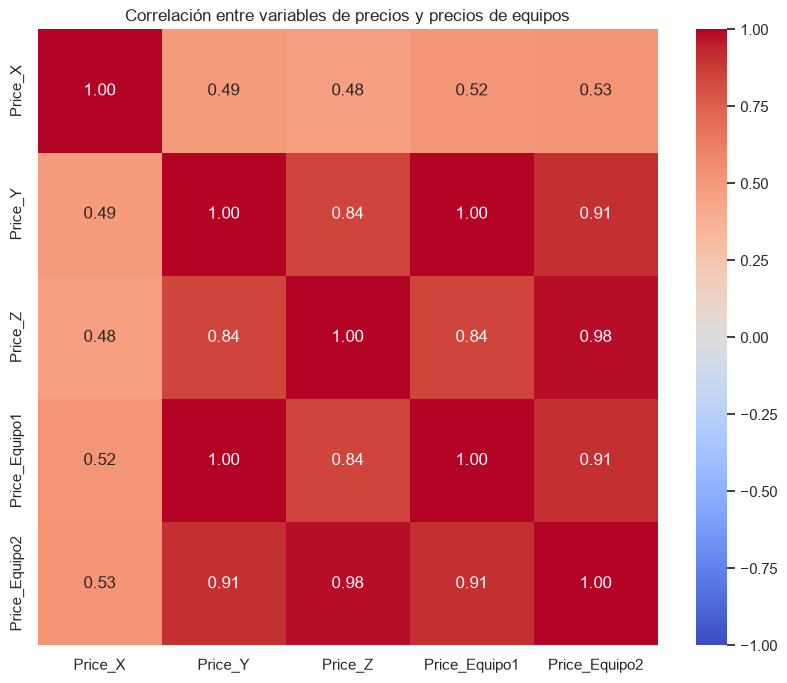

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables de precios y precios de equipos')
plt.show()

## Correlación específica con Price_Equipo1 y Price_Equipo2

In [7]:
target_cols = ['Price_Equipo1', 'Price_Equipo2']
corr_with_targets = corr.loc[['Price_X', 'Price_Y', 'Price_Z'], target_cols]
corr_with_targets

,Price_Equipo1,Price_Equipo2
Price_X,0.523371,0.530345
Price_Y,0.996618,0.912702
Price_Z,0.844013,0.982675


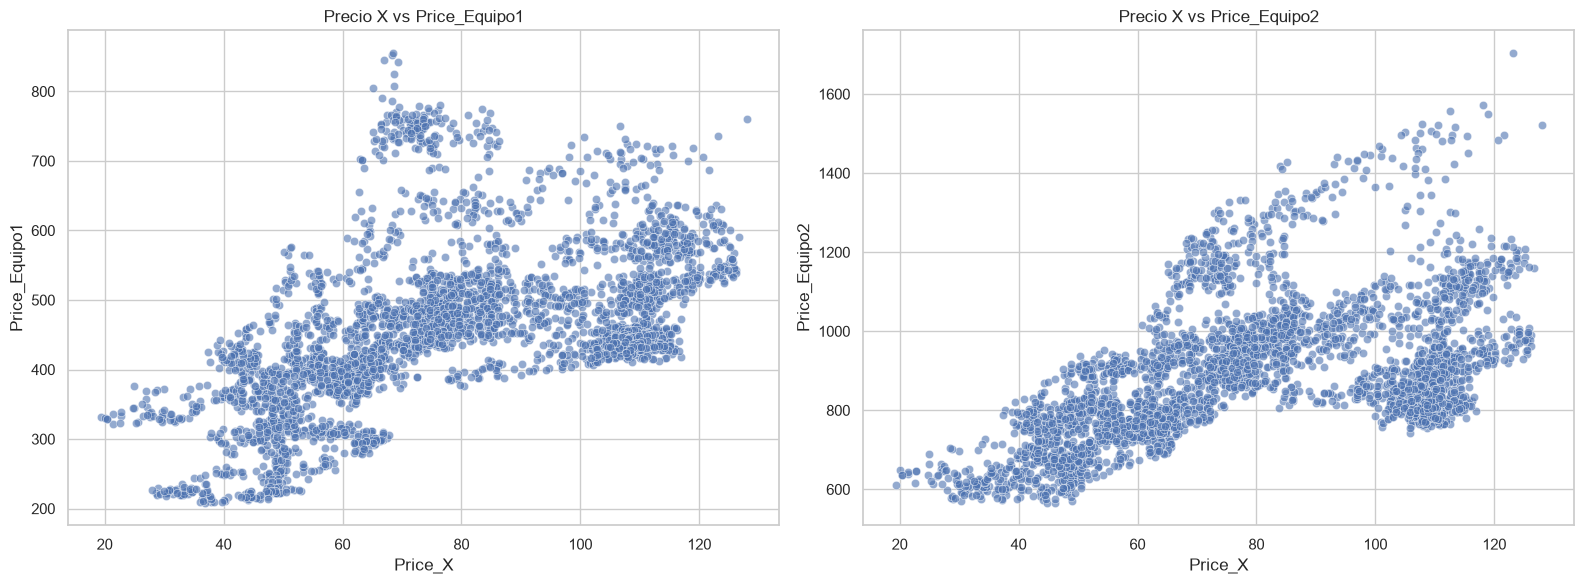

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, target_cols):
    sns.scatterplot(data=df, x='Price_X', y=target, ax=ax, alpha=0.6)
    ax.set_title(f'Precio X vs {target}')
    ax.grid(True)
plt.tight_layout()
plt.show()

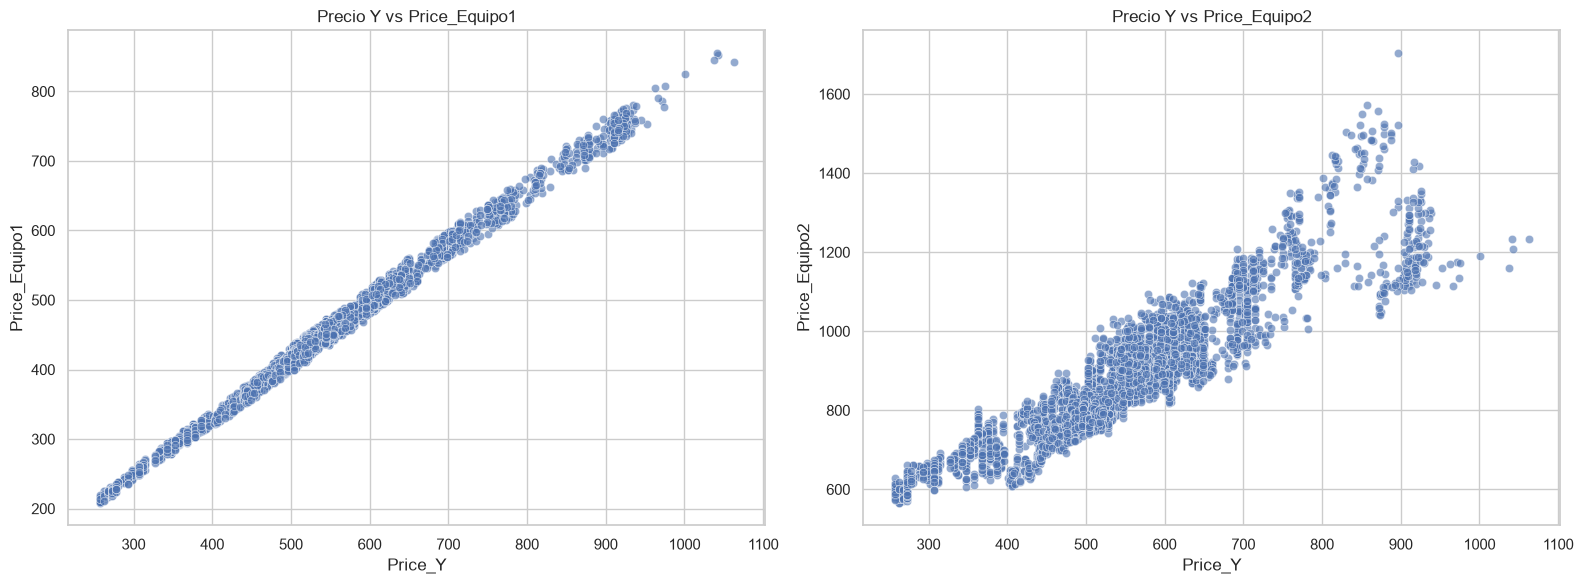

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, target_cols):
    sns.scatterplot(data=df, x='Price_Y', y=target, ax=ax, alpha=0.6)
    ax.set_title(f'Precio Y vs {target}')
    ax.grid(True)
plt.tight_layout()
plt.show()

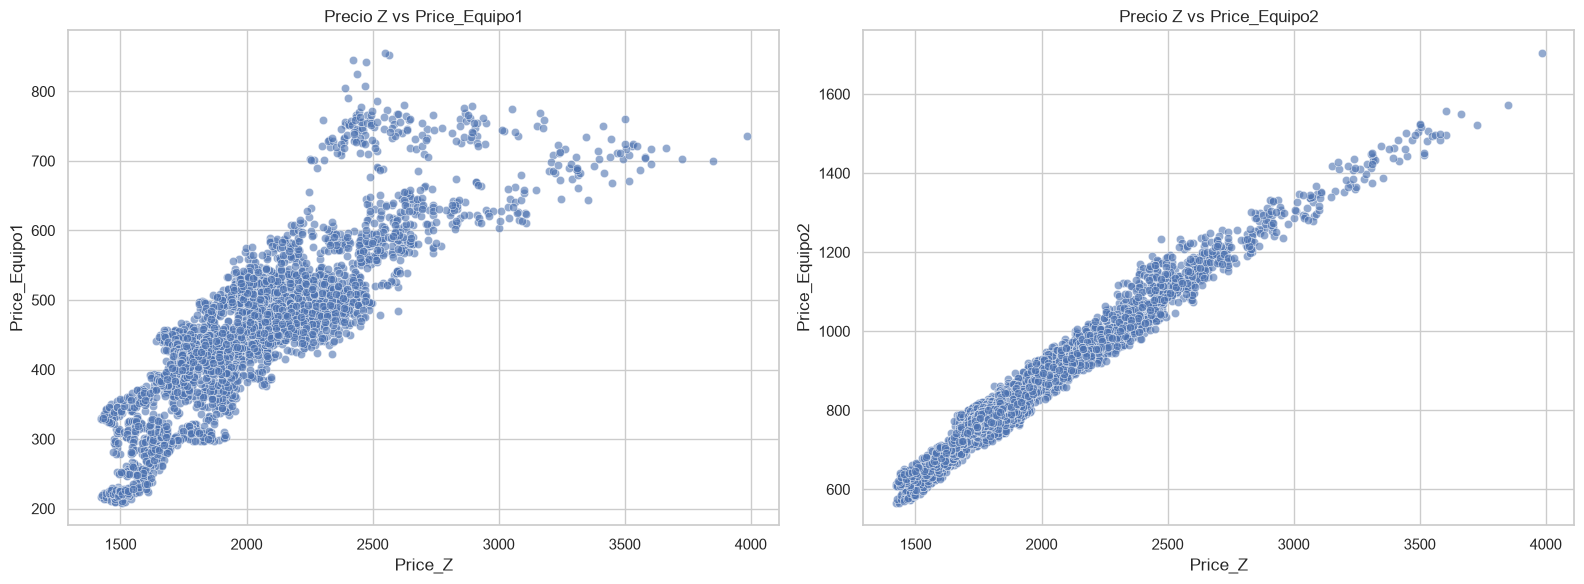

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, target_cols):
    sns.scatterplot(data=df, x='Price_Z', y=target, ax=ax, alpha=0.6)
    ax.set_title(f'Precio Z vs {target}')
    ax.grid(True)
plt.tight_layout()
plt.show()

## Preparación de datos y división en train/validation/test

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

splits = {}
for task in ['Equipo1', 'Equipo2']:
    if task == 'Equipo1':
        X = df[['Price_Y']]
        y = df['Price_Equipo1']
    else:
        X = df[['Price_Z']]
        y = df['Price_Equipo2']

    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    splits[task] = {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
    }

splits

{'Equipo1': {'X_train':       Price_Y
  2139   578.17
  1974   555.00
  77     695.00
  3505   575.00
  572    650.00
  ...       ...
  1086   517.50
  2322   482.71
  1877   475.00
  2728   476.47
  1915   445.00
  
  [2118 rows x 1 columns],
  'X_val':       Price_Y
  2394   531.88
  119    600.00
  3069   771.26
  1291   457.50
  2768   510.79
  ...       ...
  3024   926.25
  3376   645.00
  2006   572.50
  1960   510.00
  381    685.00
  
  [706 rows x 1 columns],
  'X_test':       Price_Y
  325    725.00
  3406   645.00
  3185   810.00
  746    545.00
  299    765.00
  ...       ...
  2618   465.36
  1894   430.00
  3017   922.06
  2596   495.95
  195    590.00
  
  [706 rows x 1 columns],
  'y_train': 2139    487.07
  1974    449.03
  77      558.49
  3505    480.51
  572     541.44
           ...  
  1086    438.21
  2322    399.18
  1877    391.24
  2728    383.93
  1915    371.00
  Name: Price_Equipo1, Length: 2118, dtype: float64,
  'y_val': 2394    450.15
  119     496.93
 

## Modelos de regresión y búsqueda de hiperparámetros

In [12]:
models = [
    ('LinearRegression', LinearRegression(), {}),
    ('Ridge', Ridge(), {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}),
    ('Lasso', Lasso(max_iter=10000), {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}),
    ('ElasticNet', ElasticNet(max_iter=10000), {'alpha': [0.001, 0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}),
    ('XGBRegressor', XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0), {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 4]})
]

results = []
for task, data in splits.items():
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    y_train = data['y_train']
    y_val = data['y_val']
    y_test = data['y_test']

    for name, estimator, param_grid in models:
        if param_grid:
            search = GridSearchCV(estimator, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
            search.fit(X_train, y_train)
            best_model = search.best_estimator_
            best_params = search.best_params_
        else:
            best_model = estimator.fit(X_train, y_train)
            best_params = {}

        y_val_pred = best_model.predict(X_val)
        y_test_pred = best_model.predict(X_test)

        results.append({
            'task': task,
            'model': name,
            'best_params': best_params,
            'val_mse': mean_squared_error(y_val, y_val_pred),
            'val_r2': r2_score(y_val, y_val_pred),
            'test_mse': mean_squared_error(y_test, y_test_pred),
            'test_r2': r2_score(y_test, y_test_pred)
        })

results_df = pd.DataFrame(results).sort_values(['task', 'test_mse'])
results_df

,task,model,best_params,val_mse,val_r2,test_mse,test_r2
0,Equipo1,LinearRegression,{},87.681000,0.992980,87.887631,0.992778
1,Equipo1,Ridge,{'alpha': 0.01},87.681000,0.992980,87.887631,0.992778
3,Equipo1,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.2}",87.680992,0.992980,87.887635,0.992778
2,Equipo1,Lasso,{'alpha': 0.001},87.680991,0.992980,87.887636,0.992778
4,Equipo1,XGBRegressor,"{'max_depth': 4, 'n_estimators': 50}",90.661403,0.992741,98.822843,0.991879
9,Equipo2,XGBRegressor,"{'max_depth': 3, 'n_estimators': 50}",897.466248,0.969579,815.798140,0.969341
7,Equipo2,Lasso,{'alpha': 0.001},1024.642710,0.965268,882.780221,0.966824
8,Equipo2,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.2}",1024.642712,0.965268,882.780221,0.966824
6,Equipo2,Ridge,{'alpha': 0.01},1024.642716,0.965268,882.780221,0.966824
5,Equipo2,LinearRegression,{},1024.642716,0.965268,882.780221,0.966824


## Resultados y comparación final

In [13]:
results_df

,task,model,best_params,val_mse,val_r2,test_mse,test_r2
0,Equipo1,LinearRegression,{},87.681000,0.992980,87.887631,0.992778
1,Equipo1,Ridge,{'alpha': 0.01},87.681000,0.992980,87.887631,0.992778
3,Equipo1,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.2}",87.680992,0.992980,87.887635,0.992778
2,Equipo1,Lasso,{'alpha': 0.001},87.680991,0.992980,87.887636,0.992778
4,Equipo1,XGBRegressor,"{'max_depth': 4, 'n_estimators': 50}",90.661403,0.992741,98.822843,0.991879
9,Equipo2,XGBRegressor,"{'max_depth': 3, 'n_estimators': 50}",897.466248,0.969579,815.798140,0.969341
7,Equipo2,Lasso,{'alpha': 0.001},1024.642710,0.965268,882.780221,0.966824
8,Equipo2,ElasticNet,"{'alpha': 0.001, 'l1_ratio': 0.2}",1024.642712,0.965268,882.780221,0.966824
6,Equipo2,Ridge,{'alpha': 0.01},1024.642716,0.965268,882.780221,0.966824
5,Equipo2,LinearRegression,{},1024.642716,0.965268,882.780221,0.966824


## Prueba final usando `Price_Y` y `Price_Z` juntos

In [14]:
# Probar regresión lineal con ambas variables Y y Z para cada equipo
from sklearn.linear_model import LinearRegression

results_yz = []
for task in ['Equipo1', 'Equipo2']:
    if task == 'Equipo1':
        X = df[['Price_Y']]
        y = df['Price_Equipo1']
    else:
        X = df[['Price_Z', 'Price_Y']]
        y = df['Price_Equipo2']

    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

    model = LinearRegression().fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    results_yz.append({
        'task': task,
        'model': 'LinearRegression_YZ',
        'val_mse': mean_squared_error(y_val, y_val_pred),
        'val_r2': r2_score(y_val, y_val_pred),
        'test_mse': mean_squared_error(y_test, y_test_pred),
        'test_r2': r2_score(y_test, y_test_pred)
    })

results_yz_df = pd.DataFrame(results_yz)
results_yz_df

,task,model,val_mse,val_r2,test_mse,test_r2
0,Equipo1,LinearRegression_YZ,87.681000,0.992980,87.887631,0.992778
1,Equipo2,LinearRegression_YZ,294.987773,0.990001,286.651361,0.989227


In [15]:
print('Comparación de desempeño con variables Y+Z:')
print(results_yz_df.to_string(index=False))

Comparación de desempeño con variables Y+Z:
   task               model    val_mse   val_r2   test_mse  test_r2
Equipo1 LinearRegression_YZ  87.681000 0.992980  87.887631 0.992778
Equipo2 LinearRegression_YZ 294.987773 0.990001 286.651361 0.989227


## Gráficas de predicción para los modelos seleccionados

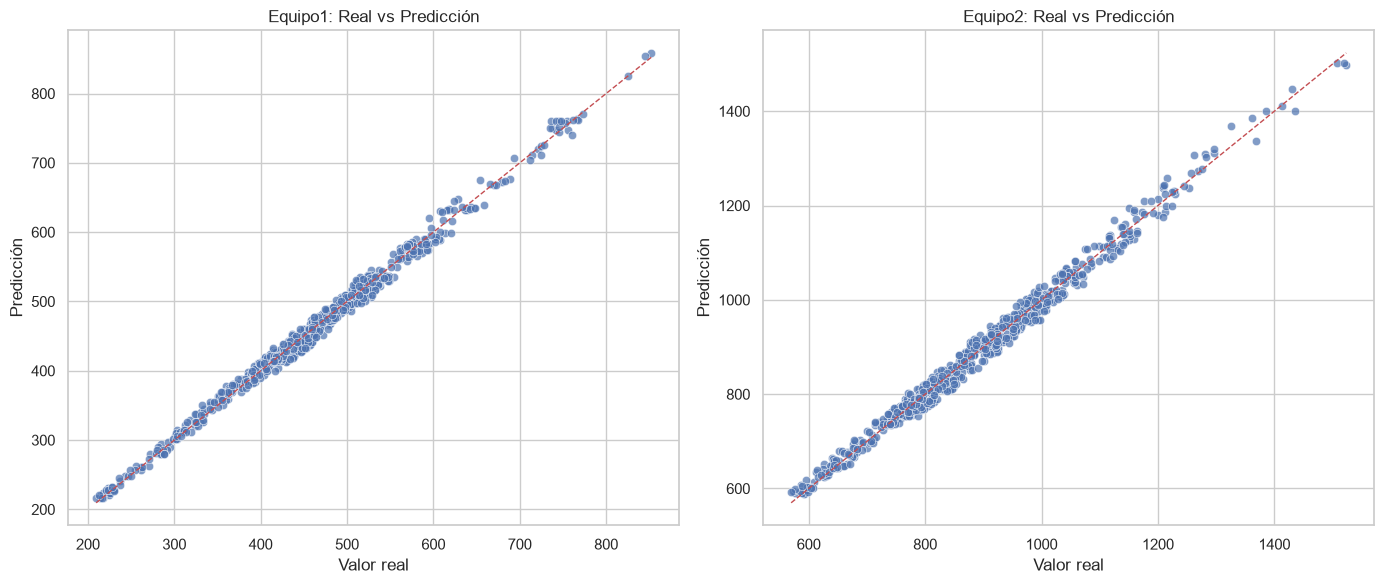

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, task in zip(axes, ['Equipo1', 'Equipo2']):
    if task == 'Equipo1':
        X = df[['Price_Y']]
        y = df['Price_Equipo1']
    else:
        X = df[['Price_Y', 'Price_Z']]
        y = df['Price_Equipo2']

    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)
    model = LinearRegression().fit(X_train, y_train)
    y_pred = model.predict(X_test)

    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax.set_title(f'{task}: Real vs Predicción')
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Predicción')
    ax.grid(True)

plt.tight_layout()
plt.show()

## Nota metodológica: de validación aleatoria a validación temporal

Los splits anteriores usan `train_test_split` de forma aleatoria. Para el análisis
exploratorio y la comparación de modelos (Linear/Ridge/Lasso/XGBoost) eso es válido
como primer filtro, pero para **proyectar hacia el futuro** no lo es.

A partir de aquí trabajamos con índice temporal explícito y validación **walk-forward**
(entrenar solo con el pasado, probar en el futuro inmediato), que es la validación que
reportamos en el informe como la real out-of-sample.

In [17]:
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Versión indexada por fecha, con frecuencia de días hábiles (para ADF/ARIMA)
df_ts = df.set_index('Date').asfreq('B').ffill()

MODELS_CONFIG = {
    'Equipo1': {'target': 'Price_Equipo1', 'features': ['Price_Y']},
    'Equipo2': {'target': 'Price_Equipo2', 'features': ['Price_Y', 'Price_Z']},
}
RAW_MATERIALS = ['Price_X', 'Price_Y', 'Price_Z']
HORIZON_DAYS = 40        # ~2 meses hábiles; se justifica abajo con la volatilidad/estacionariedad
RECENT_WINDOW_DAYS = 90
VAL_TEST_DAYS = 60
N_SIMS = 3000

df_ts.head()

,Price_X,Price_Y,Price_Z,Price_Equipo1,Price_Equipo2
Date,,,,,
2010-01-04,80.12,527.5,2225.25,434.73,931.73
2010-01-05,80.59,527.5,2246.50,449.97,968.56
2010-01-06,81.89,527.5,2302.50,444.48,960.51
2010-01-07,81.51,527.5,2306.50,440.90,960.14
2010-01-08,81.37,552.5,2261.25,448.82,949.55


## 1. Volatilidad reciente vs. histórica

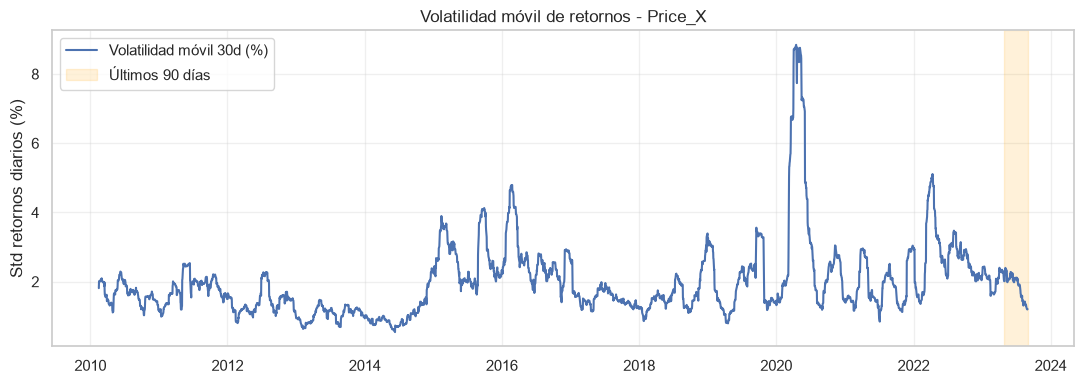

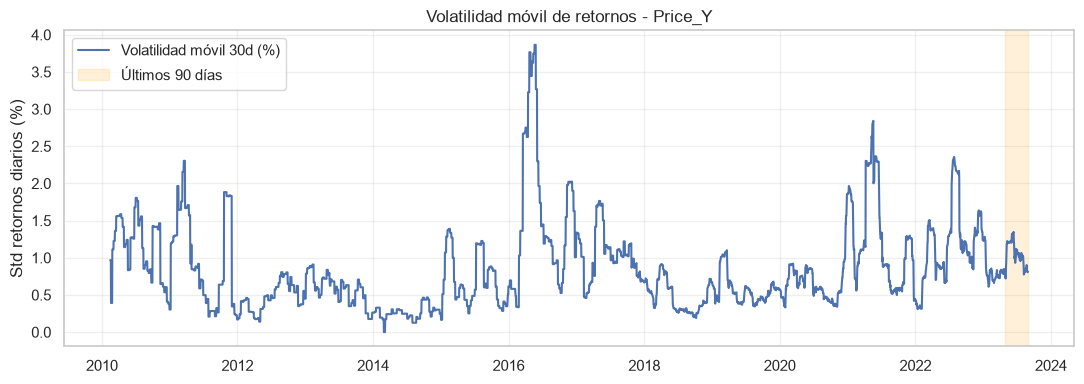

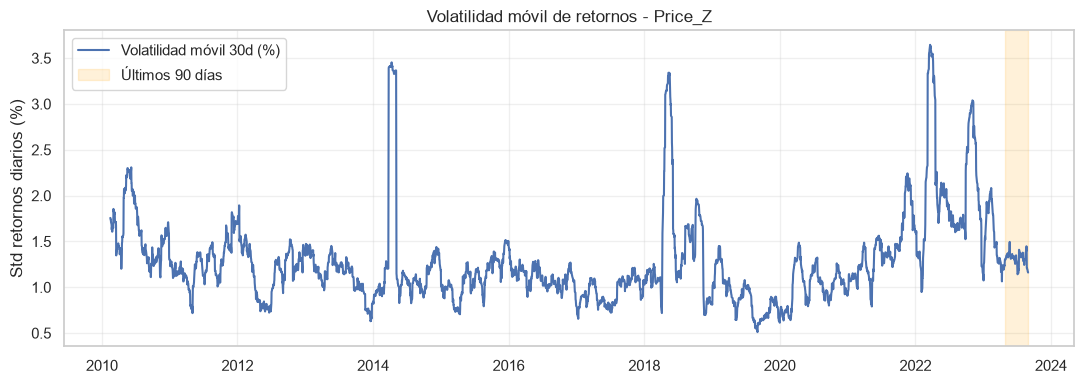

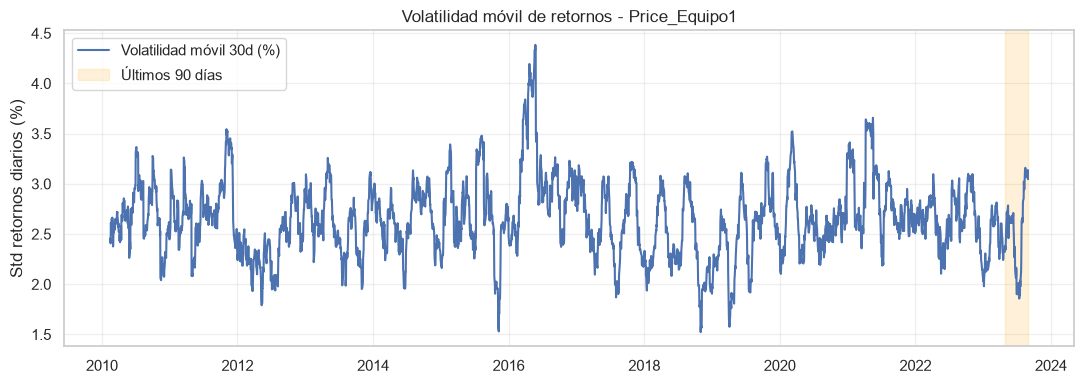

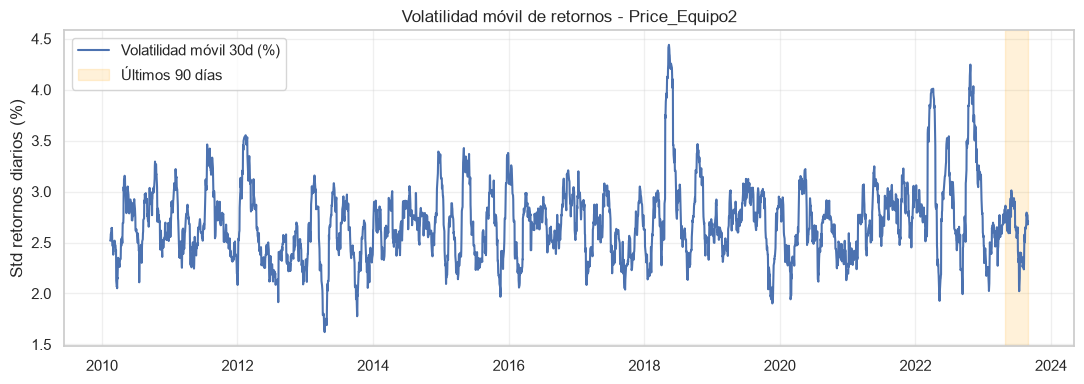

,serie,std_retornos_hist_%,std_retornos_reciente_%,ratio_reciente/hist
0,Price_X,2.250,1.778,0.79
1,Price_Y,1.041,1.049,1.01
2,Price_Z,1.368,1.279,0.93
3,Price_Equipo1,2.643,2.589,0.98
4,Price_Equipo2,2.684,2.635,0.98


In [18]:
def analyze_volatility(data, cols, recent_window_days=RECENT_WINDOW_DAYS, plot=True):
    """Compara std de retornos diarios recientes vs. histórico completo."""
    summary = []
    for col in cols:
        s = data[col].dropna()
        returns = s.pct_change().dropna()
        full_std_ret = returns.std()
        recent_std_ret = returns.tail(recent_window_days).std()
        summary.append({
            'serie': col,
            'std_retornos_hist_%': round(full_std_ret * 100, 3),
            'std_retornos_reciente_%': round(recent_std_ret * 100, 3),
            'ratio_reciente/hist': round(recent_std_ret / full_std_ret, 2) if full_std_ret else np.nan,
        })
        if plot:
            fig, ax = plt.subplots(figsize=(11, 4))
            rolling_std = returns.rolling(30).std() * 100
            ax.plot(rolling_std.index, rolling_std.values, label='Volatilidad móvil 30d (%)')
            ax.axvspan(s.index[-recent_window_days], s.index[-1], color='orange', alpha=0.15,
                       label=f'Últimos {recent_window_days} días')
            ax.set_title(f'Volatilidad móvil de retornos - {col}')
            ax.set_ylabel('Std retornos diarios (%)')
            ax.legend()
            ax.grid(alpha=0.3)
            plt.tight_layout()
            plt.show()
    return pd.DataFrame(summary)

vol_summary = analyze_volatility(df_ts, RAW_MATERIALS + ['Price_Equipo1', 'Price_Equipo2'])
vol_summary

Un ratio cercano a 1 indica que la volatilidad reciente es similar a
la histórica (soporta usar un horizonte de pronóstico moderado sin sobre-reaccionar a
ruido reciente); un ratio bien por encima o por debajo de 1 sugiere un cambio de régimen
que hay que mencionar como supuesto/limitación en el informe.

## 2. Estacionariedad (ADF) de materias primas y equipos

In [19]:
def adf_test(series, name=''):
    series = series.dropna()
    result = adfuller(series, autolag='AIC')
    return {
        'serie': name,
        'adf_stat': round(result[0], 4),
        'p_value': round(result[1], 4),
        'es_estacionaria (p<0.05)': result[1] < 0.05,
        'n_lags': result[2],
    }

def stationarity_report(data, cols):
    rows = []
    for col in cols:
        rows.append(adf_test(data[col], f'{col} (nivel)'))
        rows.append(adf_test(data[col].diff(), f'{col} (1ra diferencia)'))
    return pd.DataFrame(rows)

stat_report = stationarity_report(df_ts, RAW_MATERIALS + ['Price_Equipo1', 'Price_Equipo2'])
stat_report

,serie,adf_stat,p_value,es_estacionaria (p<0.05),n_lags
0,Price_X (nivel),-1.7067,0.4276,False,5
1,Price_X (1ra diferencia),-27.5761,0.0000,True,4
2,Price_Y (nivel),-2.4908,0.1177,False,25
3,Price_Y (1ra diferencia),-8.7723,0.0000,True,24
4,Price_Z (nivel),-2.2591,0.1855,False,20
5,Price_Z (1ra diferencia),-13.1620,0.0000,True,19
6,Price_Equipo1 (nivel),-1.8305,0.3654,False,11
7,Price_Equipo1 (1ra diferencia),-17.0896,0.0000,True,10
8,Price_Equipo2 (nivel),-1.9185,0.3234,False,6
9,Price_Equipo2 (1ra diferencia),-29.7479,0.0000,True,5


**Cómo leerlo:** si `es_estacionaria` es `False` en nivel pero `True` en 1ra diferencia,
la serie es integrada de orden 1 (I(1)) y el ARIMA de la sección 3 debe usar `d=1`. El
código de la siguiente sección toma ese resultado automáticamente.

## 3. Pronóstico de materias primas relevantes (ARIMA, selección por AIC)

c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Price_Y: mejor orden ARIMA(3, 1, 3), AIC=22924.2


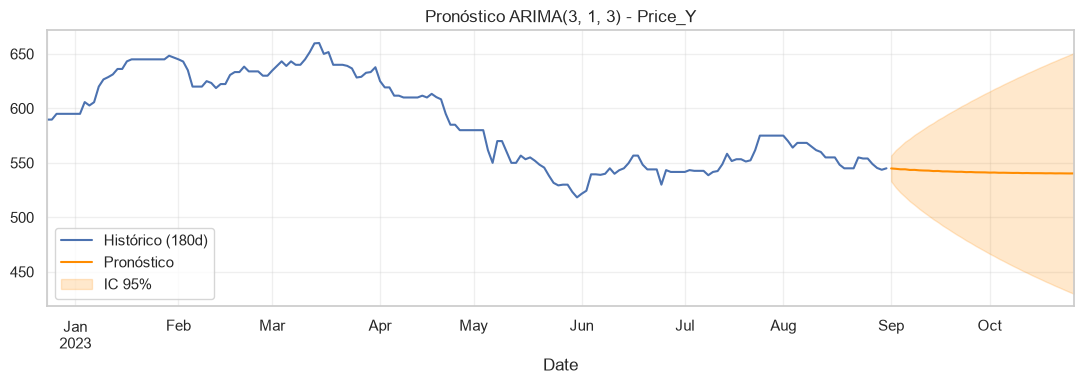

c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likel

Price_Z: mejor orden ARIMA(3, 1, 2), AIC=34546.8


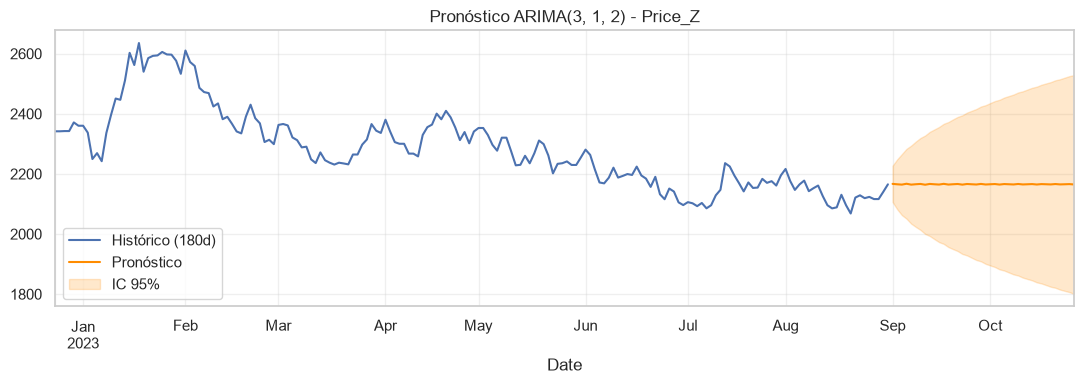

In [20]:
def fit_best_arima(series, d_hint, max_p=3, max_q=3):
    best_aic, best_order, best_model = np.inf, None, None
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            if p == 0 and q == 0:
                continue
            try:
                m = ARIMA(series, order=(p, d_hint, q)).fit()
                if m.aic < best_aic:
                    best_aic, best_order, best_model = m.aic, (p, d_hint, q), m
            except Exception:
                continue
    return best_model, best_order, best_aic

def forecast_raw_materials(data, materials, horizon=HORIZON_DAYS, stat_report_df=None):
    forecasts = {}
    for mat in materials:
        level_row = stat_report_df[stat_report_df['serie'] == f'{mat} (nivel)']
        d_hint = 0 if level_row['es_estacionaria (p<0.05)'].iloc[0] else 1

        model, order, aic = fit_best_arima(data[mat], d_hint=d_hint)
        print(f'{mat}: mejor orden ARIMA{order}, AIC={aic:.1f}')

        fc = model.get_forecast(steps=horizon)
        fc_frame = fc.summary_frame(alpha=0.05)
        future_index = pd.bdate_range(data.index[-1] + pd.Timedelta(days=1), periods=horizon)
        fc_frame.index = future_index
        forecasts[mat] = fc_frame

        fig, ax = plt.subplots(figsize=(11, 4))
        data[mat].tail(180).plot(ax=ax, label='Histórico (180d)')
        fc_frame['mean'].plot(ax=ax, label='Pronóstico', color='darkorange')
        ax.fill_between(fc_frame.index, fc_frame['mean_ci_lower'], fc_frame['mean_ci_upper'],
                         color='darkorange', alpha=0.2, label='IC 95%')
        ax.set_title(f'Pronóstico ARIMA{order} - {mat}')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    return forecasts

materials_needed = sorted({f for cfg in MODELS_CONFIG.values() for f in cfg['features']})
raw_forecasts = forecast_raw_materials(df_ts, materials_needed, stat_report_df=stat_report)

## 4. Propagación del pronóstico a los equipos (Monte Carlo → intervalo de confianza)

c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not

--- Equipo1: coeficientes ---
  Price_Y: 0.8182
  intercepto: 5.53  R2 (in-sample): 0.993


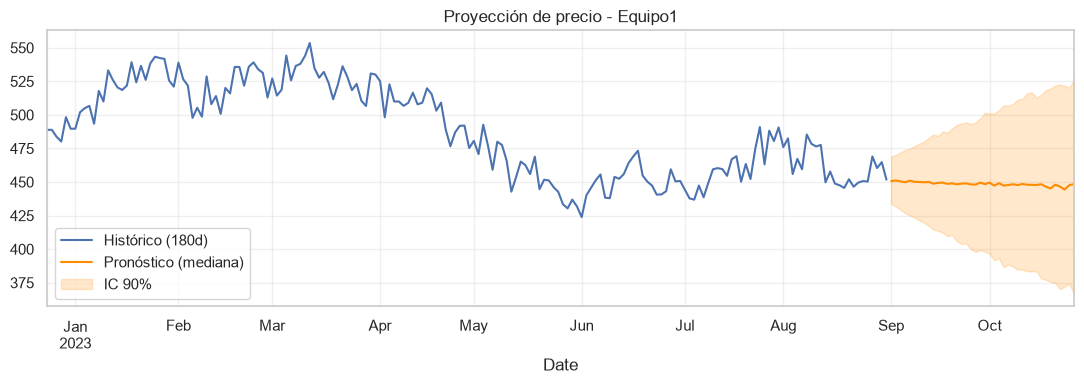

c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\frami\OneDrive\Documentos\VS Code\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not

--- Equipo2: coeficientes ---
  Price_Y: 0.3555
  Price_Z: 0.3365
  intercepto: 6.96  R2 (in-sample): 0.990


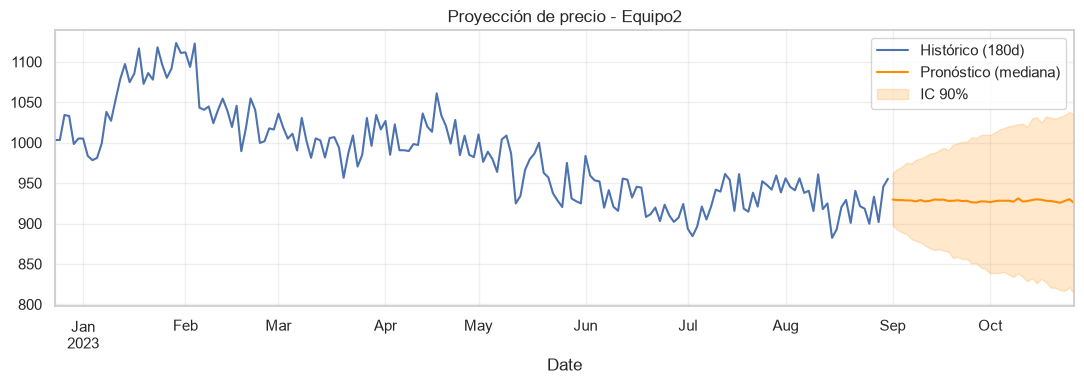

,p5,p50_mediana,p95
2023-09-01,433.652855,450.717841,468.893913
2023-09-04,431.756041,451.159693,470.268372
2023-09-05,429.411562,450.463904,472.066221
2023-09-06,426.670940,449.859895,474.077261
2023-09-07,425.285403,451.004237,474.715565


In [21]:
def propagate_to_equipos(data, models_config, raw_forecasts, n_sims=N_SIMS, horizon=HORIZON_DAYS):
    """
    1. Reajusta la regresión lineal (ya validada arriba) con todo el histórico.
    2. Simula n_sims trayectorias futuras de cada materia prima ~ N(mean, se) del ARIMA.
    3. Pasa cada trayectoria por la regresión y suma ruido bootstrap de los residuales.
    4. Reporta percentiles 5/50/95 por día como intervalo de confianza del precio del equipo.
    """
    results = {}
    rng = np.random.default_rng(42)
    for equipo, cfg in models_config.items():
        target, features = cfg['target'], cfg['features']
        X = data[features]
        y = data[target]

        reg = LinearRegression().fit(X, y)
        residuals = y.values - reg.predict(X)

        sims = np.zeros((n_sims, horizon))
        for i in range(n_sims):
            sim_features = np.column_stack([
                rng.normal(raw_forecasts[f]['mean'].values, raw_forecasts[f]['mean_se'].values)
                for f in features
            ])
            pred = reg.predict(sim_features) + rng.choice(residuals, size=horizon, replace=True)
            sims[i, :] = pred

        future_index = raw_forecasts[features[0]].index
        result_df = pd.DataFrame({
            'p5': np.percentile(sims, 5, axis=0),
            'p50_mediana': np.percentile(sims, 50, axis=0),
            'p95': np.percentile(sims, 95, axis=0),
        }, index=future_index)
        results[equipo] = result_df

        print(f'--- {equipo}: coeficientes ---')
        for f, coefv in zip(features, reg.coef_):
            print(f'  {f}: {coefv:.4f}')
        print(f'  intercepto: {reg.intercept_:.2f}  R2 (in-sample): {reg.score(X, y):.3f}')

        fig, ax = plt.subplots(figsize=(11, 4))
        y.tail(180).plot(ax=ax, label='Histórico (180d)')
        result_df['p50_mediana'].plot(ax=ax, label='Pronóstico (mediana)', color='darkorange')
        ax.fill_between(result_df.index, result_df['p5'], result_df['p95'],
                         color='darkorange', alpha=0.2, label='IC 90%')
        ax.set_title(f'Proyección de precio - {equipo}')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    return results

equipo_forecasts = propagate_to_equipos(df_ts, MODELS_CONFIG, raw_forecasts)
equipo_forecasts['Equipo1'].head()

## 5. Validación walk-forward (split cronológico, sin data leakage)

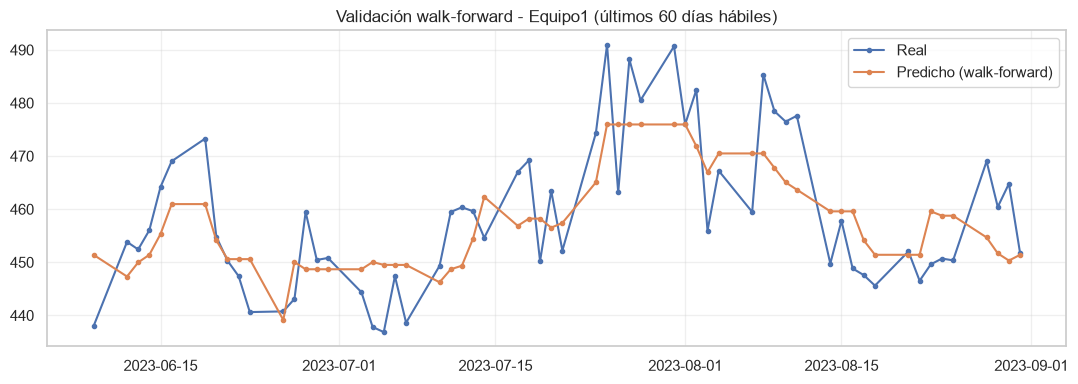

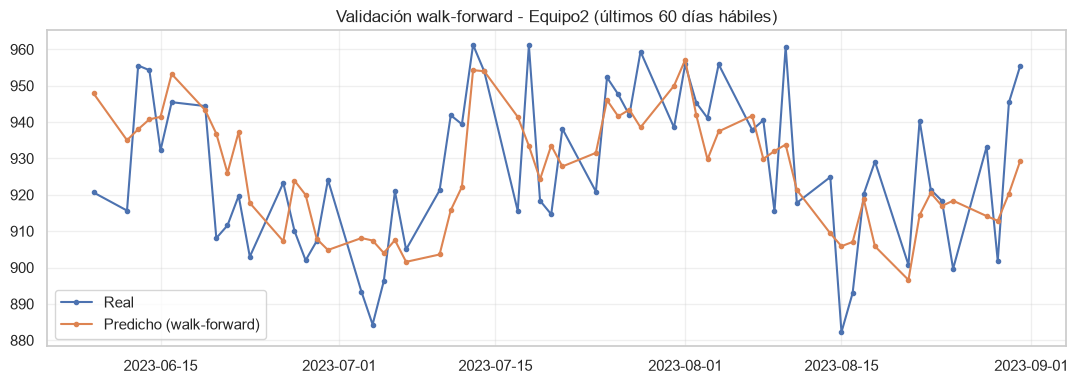

,equipo,MAE,RMSE,MAPE_%
0,Equipo1,7.92,9.05,1.72
1,Equipo2,13.69,16.07,1.48


In [22]:
from sklearn.metrics import mean_absolute_error

def walk_forward_validation(data, models_config, test_days=VAL_TEST_DAYS):
    train = data.iloc[:-test_days]
    test = data.iloc[-test_days:]
    metrics_rows = []
    for equipo, cfg in models_config.items():
        target, features = cfg['target'], cfg['features']
        reg = LinearRegression().fit(train[features], train[target])
        y_pred = reg.predict(test[features])
        y_true = test[target].values

        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        metrics_rows.append({'equipo': equipo, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE_%': round(mape, 2)})

        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(test.index, y_true, label='Real', marker='o', markersize=3)
        ax.plot(test.index, y_pred, label='Predicho (walk-forward)', marker='o', markersize=3)
        ax.set_title(f'Validación walk-forward - {equipo} (últimos {test_days} días hábiles)')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    return pd.DataFrame(metrics_rows)

val_metrics = walk_forward_validation(df_ts, MODELS_CONFIG)
val_metrics

In [23]:
equipo_forecasts['Equipo1'].tail()

,p5,p50_mediana,p95
2023-10-20,374.755909,447.957035,521.844695
2023-10-23,370.270832,446.637445,522.549112
2023-10-24,372.117318,444.368094,521.764019
2023-10-25,374.042268,447.674148,520.259521
2023-10-26,366.732928,448.412613,526.244223


In [24]:
equipo_forecasts['Equipo2'].tail()

,p5,p50_mediana,p95
2023-10-20,820.532835,926.862493,1029.678821
2023-10-23,817.640378,925.674738,1031.912350
2023-10-24,816.756573,927.848604,1033.935802
2023-10-25,821.299730,930.071337,1037.956158
2023-10-26,813.047725,925.360915,1034.745980


El horizonte de 40 días hábiles como rango completo, pero marcar los primeros ~20 días como la ventana de "alta confianza" para presupuesto, y el resto como orientación direccional.

## 6. Exportar resultados para el agente de IA

In [25]:
import json
from pathlib import Path

export_dir = Path('agent_data')
export_dir.mkdir(exist_ok=True)

# Coeficientes y métricas de cada modelo (para que el agente pueda explicar el "por qué")
model_summaries = {}
for equipo, cfg in MODELS_CONFIG.items():
    target, features = cfg['target'], cfg['features']
    reg = LinearRegression().fit(df_ts[features], df_ts[target])
    row = val_metrics[val_metrics['equipo'] == equipo].iloc[0]
    model_summaries[equipo] = {
        'features': features,
        'coeficientes': dict(zip(features, reg.coef_.tolist())),
        'intercepto': float(reg.intercept_),
        'r2_in_sample': float(reg.score(df_ts[features], df_ts[target])),
        'validacion_walk_forward': {
            'MAE': float(row['MAE']), 'RMSE': float(row['RMSE']), 'MAPE_%': float(row['MAPE_%'])
        },
        'horizonte_dias': HORIZON_DAYS,
    }

with open(export_dir / 'model_summaries.json', 'w') as f:
    json.dump(model_summaries, f, indent=2, ensure_ascii=False)

# Pronóstico (p5/mediana/p95) por equipo, indexado por fecha
for equipo, res in equipo_forecasts.items():
    out = res.reset_index().rename(columns={'index': 'date'})
    out['date'] = out['date'].astype(str)
    out.to_json(export_dir / f'forecast_{equipo}.json', orient='records', indent=2)

print('Exportado en', export_dir.resolve())
print(model_summaries)

# --- Pronóstico ARIMA de las materias primas (Y, Z) ---
for mat, res in raw_forecasts.items():
    out = res.reset_index().rename(columns={'index': 'date'})
    out['date'] = out['date'].astype(str)
    out = out.rename(columns={'mean': 'media', 'mean_ci_lower': 'ci_lower', 'mean_ci_upper': 'ci_upper'})
    out[['date', 'media', 'ci_lower', 'ci_upper']].to_json(
        export_dir / f'forecast_{mat}.json', orient='records', indent=2)

# --- Histórico completo (para que el agente pueda consultar cualquier fecha pasada) ---
hist_out = df_ts.reset_index()
hist_out['Date'] = hist_out['Date'].astype(str)
hist_out.to_json(export_dir / 'historico.json', orient='records', indent=2)

print('Pronósticos de materias primas e histórico exportados también.')


Exportado en C:\Users\frami\OneDrive\Documentos\VS Code\agent_data
{'Equipo1': {'features': ['Price_Y'], 'coeficientes': {'Price_Y': 0.8181625847641856}, 'intercepto': 5.5304929863798975, 'r2_in_sample': 0.9932479648169428, 'validacion_walk_forward': {'MAE': 7.92, 'RMSE': 9.05, 'MAPE_%': 1.72}, 'horizonte_dias': 40}, 'Equipo2': {'features': ['Price_Y', 'Price_Z'], 'coeficientes': {'Price_Y': 0.3555034605328033, 'Price_Z': 0.3364613983990161}, 'intercepto': 6.9628666445477165, 'r2_in_sample': 0.9897127195662356, 'validacion_walk_forward': {'MAE': 13.69, 'RMSE': 16.07, 'MAPE_%': 1.48}, 'horizonte_dias': 40}}
Pronósticos de materias primas e histórico exportados también.


### 6.1 Exportar también el pronóstico de las materias primas (Y, Z)

In [26]:
# Complementa la exportación de la sección 6: guarda también el pronóstico ARIMA
# de cada materia prima usada (no solo el precio final del equipo), para que el
# agente pueda explicar qué hizo que el precio del equipo se moviera.

raw_material_summaries = {}
for mat in materials_needed:
    level_row = stat_report[stat_report['serie'] == f'{mat} (nivel)'].iloc[0]
    raw_material_summaries[mat] = {
        'es_estacionaria_en_nivel': bool(level_row['es_estacionaria (p<0.05)']),
        # volatilidad ya calculada en la sección 1
        'volatilidad': vol_summary[vol_summary['serie'] == mat].to_dict('records')[0],
    }

with open(export_dir / 'raw_material_summaries.json', 'w') as f:
    json.dump(raw_material_summaries, f, indent=2, ensure_ascii=False)

for mat, fc_frame in raw_forecasts.items():
    out = fc_frame.reset_index().rename(columns={'index': 'date'})
    out['date'] = out['date'].astype(str)
    out = out[['date', 'mean', 'mean_ci_lower', 'mean_ci_upper']]
    out.to_json(export_dir / f'forecast_raw_{mat}.json', orient='records', indent=2)

print('Materias primas exportadas:', list(raw_forecasts.keys()))

Materias primas exportadas: ['Price_Y', 'Price_Z']
